In [ ]:
import pandas as pd
import os

# 0. Convert XLSX to CSV
excel_files = [
    'Ticket sale data 2022.xlsx',
    'Ticket sale data 2023.xlsx',
    'Ticket sale data 2024.xlsx',
    'Ticket sale data 2025.xlsx',
    'Ticket sale data 2026.xlsx'
]

csv_files = []

print("Converting Excel files to CSV...")
for f in excel_files:
    csv_name = f.replace('.xlsx', '.csv')
    if os.path.exists(f):
        df_temp = pd.read_excel(f)
        df_temp.to_csv(csv_name, index=False)
        csv_files.append(csv_name)
        print(f"Converted {f} -> {csv_name}")
    else:
        print(f"Warning: {f} not found, skipping conversion.")

Converting Excel files to CSV...
Converted Ticket sale data 2022.xlsx -> Ticket sale data 2022.csv
Converted Ticket sale data 2023.xlsx -> Ticket sale data 2023.csv
Converted Ticket sale data 2024.xlsx -> Ticket sale data 2024.csv
Converted Ticket sale data 2025.xlsx -> Ticket sale data 2025.csv
Converted Ticket sale data 2026.xlsx -> Ticket sale data 2026.csv


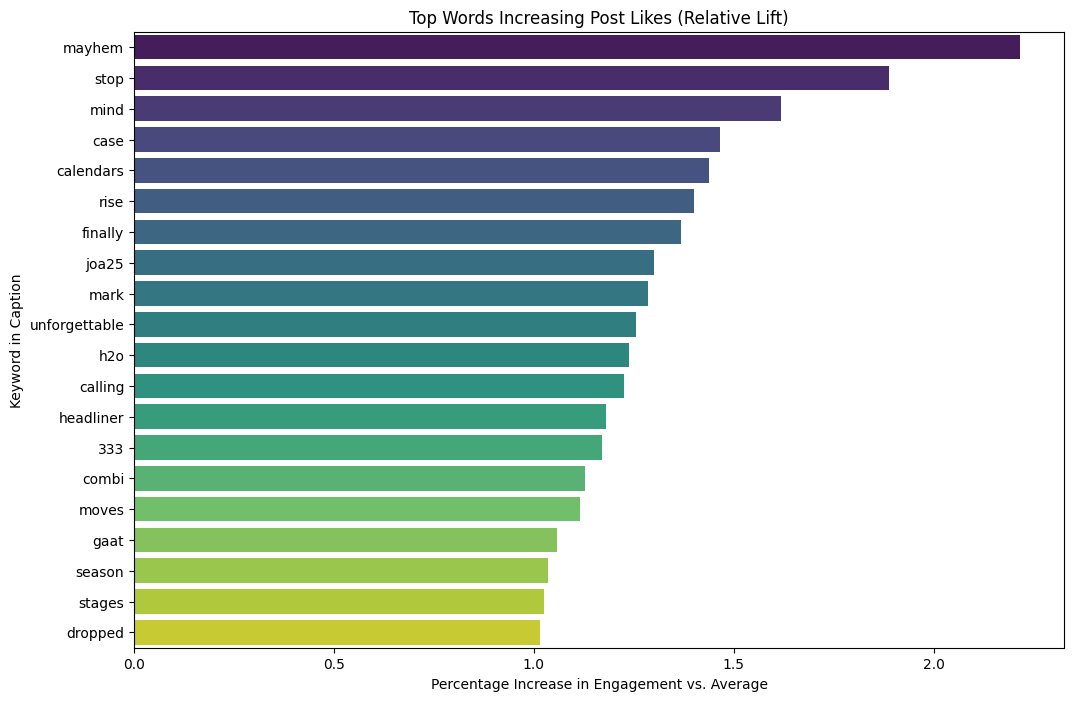

Analysis complete for likes. Results saved to 'word_impact_likes_analysis.csv'.


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load Data
file_path = 'instagram_posts_clean_full_2019_2026 (1).csv'
df = pd.read_csv(file_path)

# 2. Preprocessing Function
def clean_text(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\@\w+', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text)  # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text

df['clean_caption'] = df['caption'].apply(clean_text)

# 3. Define the "Success" Metric
target_metric = 'likes'
threshold = df[target_metric].median()
df['high_performance'] = (df[target_metric] > threshold).astype(int)

# 4. Extract Word Features
# We use CountVectorizer to find words that appear in at least 5 posts
stop_words = 'english'
cv = CountVectorizer(stop_words=stop_words, min_df=5, binary=True)
word_matrix = cv.fit_transform(df['clean_caption'])
word_df = pd.DataFrame(word_matrix.toarray(), columns=cv.get_feature_names_out())

# 5. Analyze Correlation
# Calculate the average 'Likes' for posts containing a word vs. those without
word_impact = []
for word in word_df.columns:
    has_word = df[word_df[word] == 1][target_metric].mean()
    no_word = df[word_df[word] == 0][target_metric].mean()
    lift = (has_word - no_word) / no_word if no_word > 0 else 0
    word_impact.append({'word': word, 'avg_likes_with': has_word, 'lift': lift, 'count': word_df[word].sum()})

impact_df = pd.DataFrame(word_impact).sort_values(by='lift', ascending=False)

# 6. Visualization
plt.figure(figsize=(12, 8))
top_words = impact_df.head(20)
sns.barplot(data=top_words, x='lift', y='word', hue='word', palette='viridis', legend=False)
plt.title(f'Top Words Increasing Post {target_metric.capitalize()} (Relative Lift)')
plt.xlabel('Percentage Increase in Engagement vs. Average')
plt.ylabel('Keyword in Caption')
plt.show()

# 7. Export for Research
impact_df.to_csv('word_impact_likes_analysis.csv', index=False)
print(f"Analysis complete for {target_metric}. Results saved to 'word_impact_likes_analysis.csv'.")

Loading and merging ticket sales data...
Calculating Sales Lift per post...


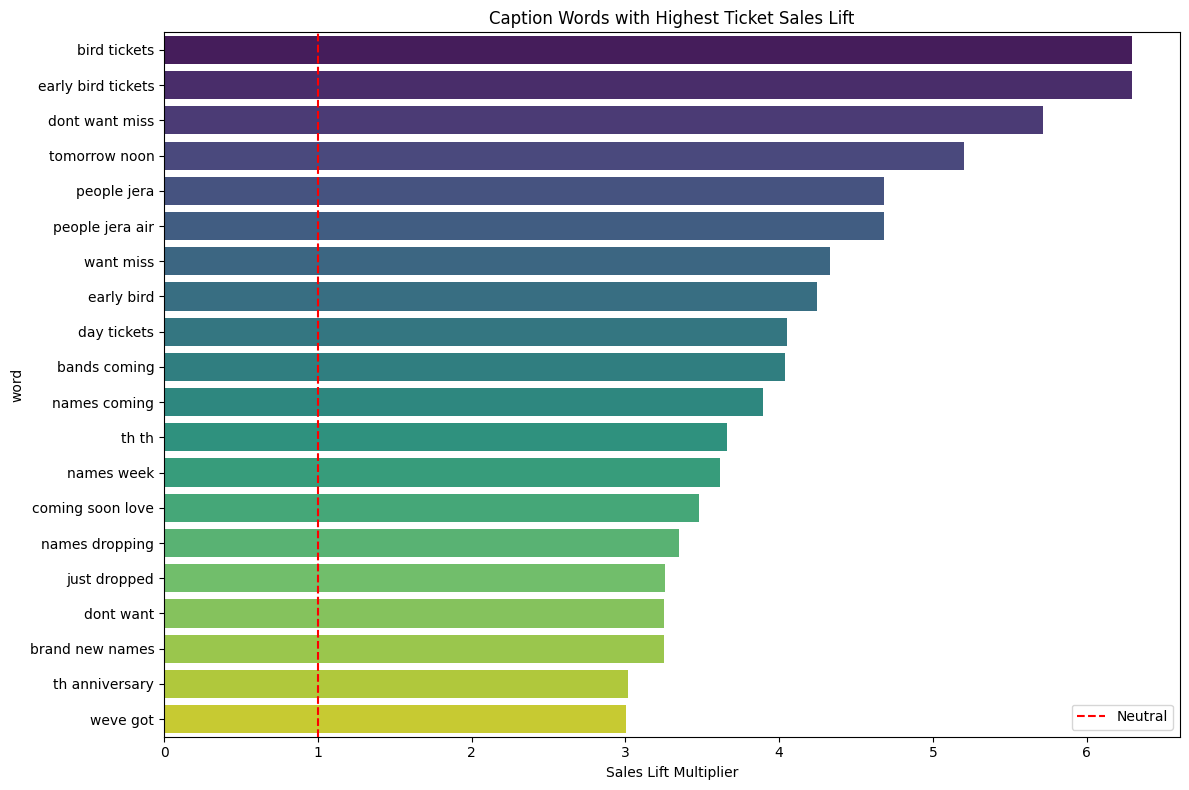

Analysis complete. Results saved to 'final_sales_word_impact.csv'.


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. SETUP FILENAMES
insta_file = 'instagram_posts_clean_full_2019_2026 (1).csv'
sales_files = [
    'Ticket sale data 2022.xlsx',
    'Ticket sale data 2023.xlsx',
    'Ticket sale data 2024.xlsx',
    'Ticket sale data 2025.xlsx',
    'Ticket sale data 2026.xlsx'
]

# 2. LOAD AND MERGE TICKET SALES
print("Loading and merging ticket sales data...")
all_sales = []
for f in sales_files:
    try:
        # Using read_excel for .xlsx files
        temp = pd.read_excel(f)
        all_sales.append(temp)
    except FileNotFoundError:
        print(f"Skipping {f} - File not found.")

if not all_sales:
    print("Error: No sales files were loaded. Please check file names.")
else:
    full_sales = pd.concat(all_sales, ignore_index=True)
    # Adjusting column name based on likely Excel structure from previous error context
    date_col = '# created' if '# created' in full_sales.columns else full_sales.columns[0]
    full_sales['created_dt'] = pd.to_datetime(full_sales[date_col], utc=True, errors='coerce')
    full_sales['date'] = full_sales['created_dt'].dt.date

    # Aggregate daily sales counts
    count_col = 'count(1)' if 'count(1)' in full_sales.columns else full_sales.columns[1]
    daily_sales = full_sales.groupby('date')[count_col].sum().reset_index()
    daily_sales.columns = ['date', 'tickets_sold']
    daily_sales = daily_sales.dropna()

    # 3. LOAD INSTAGRAM DATA
    insta_df = pd.read_csv(insta_file)
    insta_df['post_date_dt'] = pd.to_datetime(insta_df['post_date']).dt.date

    # 4. CALCULATE "SALES LIFT"
    def calculate_lift(row, sales_data, window_days=3, baseline_days=14):
        post_date = row['post_date_dt']
        after_mask = (sales_data['date'] >= post_date) & (sales_data['date'] < post_date + pd.Timedelta(days=window_days))
        avg_after = sales_data.loc[after_mask, 'tickets_sold'].mean()
        before_mask = (sales_data['date'] >= post_date - pd.Timedelta(days=baseline_days)) & (sales_data['date'] < post_date)
        avg_before = sales_data.loc[before_mask, 'tickets_sold'].mean()
        if pd.isna(avg_before) or avg_before == 0: return np.nan
        return avg_after / avg_before

    print("Calculating Sales Lift per post...")
    insta_df['sales_lift'] = insta_df.apply(lambda x: calculate_lift(x, daily_sales), axis=1)

    # 5. NLP PREPROCESSING
    def clean_caption(text):
        if pd.isna(text): return ""
        text = text.lower()
        text = re.sub(r'#\w+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        return text

    insta_df['clean_text'] = insta_df['caption'].apply(clean_caption)
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(2, 3), min_df=5)
    X = vectorizer.fit_transform(insta_df['clean_text'])
    words = vectorizer.get_feature_names_out()

    # 6. ANALYZE IMPACT
    word_data = []
    for i, word in enumerate(words):
        has_word = X[:, i].toarray().flatten() > 0
        lift_with = insta_df[has_word]['sales_lift'].dropna().mean()
        if not np.isnan(lift_with):
            word_data.append({'word': word, 'avg_sales_lift': lift_with, 'occurrence_count': has_word.sum()})

    impact_results = pd.DataFrame(word_data).sort_values('avg_sales_lift', ascending=False)

    # 7. VISUALIZE
    plt.figure(figsize=(12, 8))
    top_20 = impact_results.head(20)
    sns.barplot(data=top_20, x='avg_sales_lift', y='word', hue='word', palette='viridis', legend=False)
    plt.axvline(x=1.0, color='red', linestyle='--', label='Neutral')
    plt.title('Caption Words with Highest Ticket Sales Lift')
    plt.xlabel('Sales Lift Multiplier')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8. SAVE
    impact_results.to_csv('final_sales_word_impact.csv', index=False)
    print("Analysis complete. Results saved to 'final_sales_word_impact.csv'.")

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. SETUP FILENAMES (Using CSVs now)
insta_file = 'instagram_posts_clean_full_2019_2026 (1).csv'
sales_csv_files = [
    'Ticket sale data 2022.csv',
    'Ticket sale data 2023.csv',
    'Ticket sale data 2024.csv',
    'Ticket sale data 2025.csv',
    'Ticket sale data 2026.csv'
]

# 2. LOAD AND MERGE TICKET SALES
print("Loading and merging ticket sales data from CSVs...")
all_sales = []
for f in sales_csv_files:
    try:
        temp = pd.read_csv(f)
        all_sales.append(temp)
    except FileNotFoundError:
        print(f"Skipping {f} - File not found.")

if not all_sales:
    print("Error: No sales files were loaded.")
else:
    full_sales = pd.concat(all_sales, ignore_index=True)
    date_col = '# created' if '# created' in full_sales.columns else full_sales.columns[0]
    full_sales['created_dt'] = pd.to_datetime(full_sales[date_col], utc=True, errors='coerce')
    full_sales['date'] = full_sales['created_dt'].dt.date

    count_col = 'count(1)' if 'count(1)' in full_sales.columns else full_sales.columns[1]
    daily_sales = full_sales.groupby('date')[count_col].sum().reset_index()
    daily_sales.columns = ['date', 'tickets_sold']
    daily_sales = daily_sales.dropna()

    # 3. LOAD INSTAGRAM DATA
    insta_df = pd.read_csv(insta_file)
    insta_df['post_date_dt'] = pd.to_datetime(insta_df['post_date']).dt.date

    # 4. CALCULATE "SALES LIFT"
    def calculate_lift(row, sales_data, window_days=3, baseline_days=14):
        post_date = row['post_date_dt']
        after_mask = (sales_data['date'] >= post_date) & (sales_data['date'] < post_date + pd.Timedelta(days=window_days))
        avg_after = sales_data.loc[after_mask, 'tickets_sold'].mean()
        before_mask = (sales_data['date'] >= post_date - pd.Timedelta(days=baseline_days)) & (sales_data['date'] < post_date)
        avg_before = sales_data.loc[before_mask, 'tickets_sold'].mean()
        if pd.isna(avg_before) or avg_before == 0: return np.nan
        return avg_after / avg_before

    print("Calculating Sales Lift per post...")
    insta_df['sales_lift'] = insta_df.apply(lambda x: calculate_lift(x, daily_sales), axis=1)

    # 5. NLP PREPROCESSING
    def clean_caption(text):
        if pd.isna(text): return ""
        text = text.lower()
        text = re.sub(r'#\w+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        return text

    insta_df['clean_text'] = insta_df['caption'].apply(clean_caption)
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(2, 3), min_df=5)
    X = vectorizer.fit_transform(insta_df['clean_text'])
    words = vectorizer.get_feature_names_out()

    # 6. ANALYZE IMPACT
    word_data = []
    for i, word in enumerate(words):
        has_word = X[:, i].toarray().flatten() > 0
        lift_with = insta_df[has_word]['sales_lift'].dropna().mean()
        if not np.isnan(lift_with):
            word_data.append({'word': word, 'avg_sales_lift': lift_with, 'occurrence_count': has_word.sum()})

    impact_results = pd.DataFrame(word_data).sort_values('avg_sales_lift', ascending=False)
    impact_results.to_csv('final_sales_word_impact.csv', index=False)
    print("Analysis complete. Results saved to 'final_sales_word_impact.csv'.")

Loading and merging ticket sales data from CSVs...
Calculating Sales Lift per post...
Analysis complete. Results saved to 'final_sales_word_impact.csv'.


### Top Bigrams with Highest Ticket Sales Lift

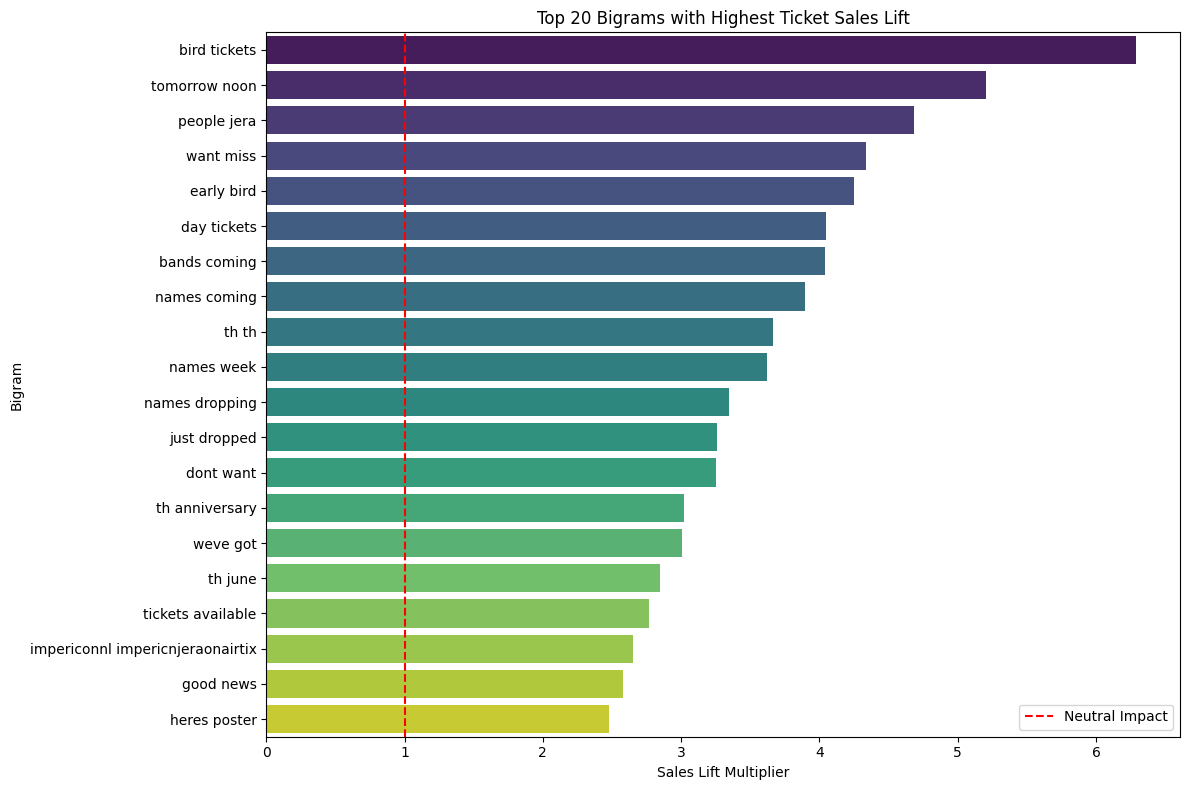

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load impact_results from the CSV file
impact_results = pd.read_csv('final_sales_word_impact.csv')

# Filter for bigrams
bigrams = impact_results[impact_results['word'].apply(lambda x: len(x.split()) == 2)]

plt.figure(figsize=(12, 8))
top_20_bigrams = bigrams.head(20)
sns.barplot(data=top_20_bigrams, x='avg_sales_lift', y='word', hue='word', palette='viridis', legend=False)
plt.axvline(x=1.0, color='red', linestyle='--', label='Neutral Impact')
plt.title('Top 20 Bigrams with Highest Ticket Sales Lift')
plt.xlabel('Sales Lift Multiplier')
plt.ylabel('Bigram')
plt.legend()
plt.tight_layout()
plt.show()

### Top Trigrams with Highest Ticket Sales Lift

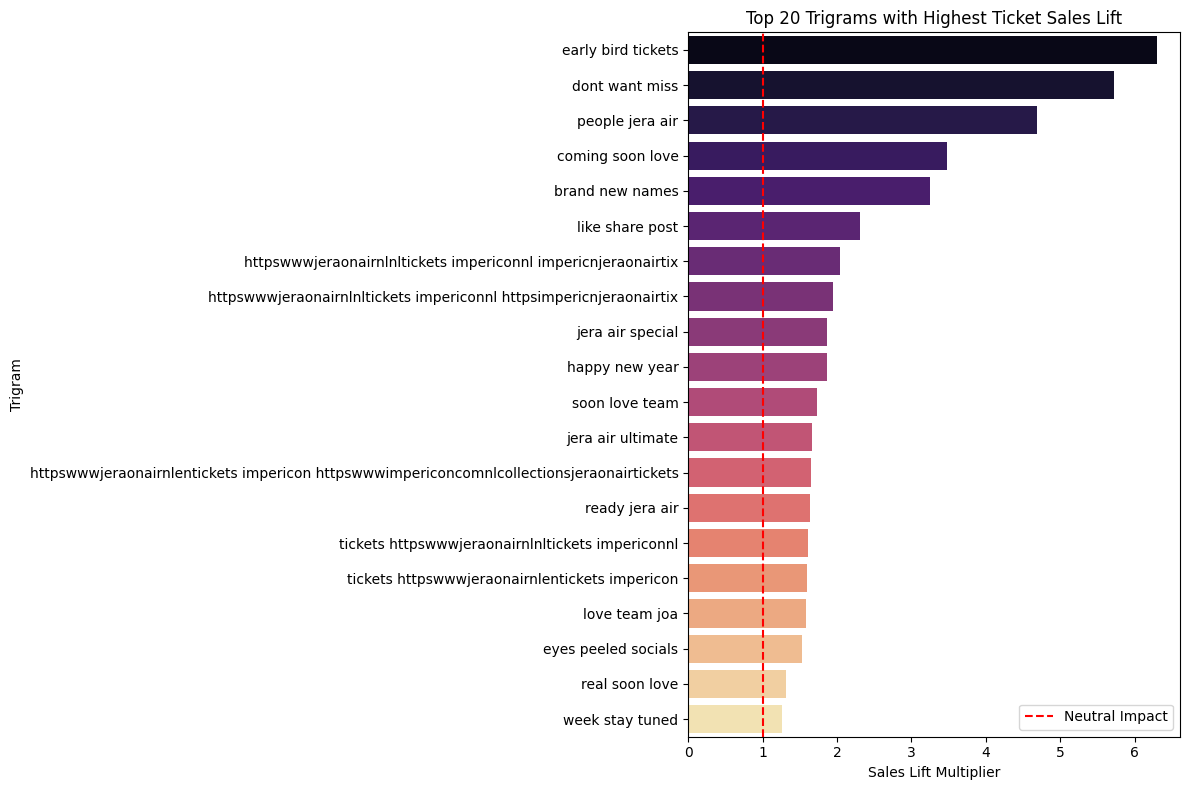

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load impact_results from the CSV file
impact_results = pd.read_csv('final_sales_word_impact.csv')

# Filter for trigrams
trigrams = impact_results[impact_results['word'].apply(lambda x: len(x.split()) == 3)]

plt.figure(figsize=(12, 8))
top_20_trigrams = trigrams.head(20)
sns.barplot(data=top_20_trigrams, x='avg_sales_lift', y='word', hue='word', palette='magma', legend=False)
plt.axvline(x=1.0, color='red', linestyle='--', label='Neutral Impact')
plt.title('Top 20 Trigrams with Highest Ticket Sales Lift')
plt.xlabel('Sales Lift Multiplier')
plt.ylabel('Trigram')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import re

# 1. Load the datasets
print("Loading datasets...")
# Use the correct filename based on your directory structure
master_df = pd.read_csv('final_master_with_time_features.csv')
insta_df = pd.read_csv('instagram_posts_clean_full_2019_2026 (1).csv')
impact_df = pd.read_csv('final_sales_word_impact.csv')

# 2. Build the Impact Dictionary
impact_df['word'] = impact_df['word'].astype(str).str.lower()
impact_df['avg_sales_lift'] = pd.to_numeric(impact_df['avg_sales_lift'], errors='coerce')
impact_df = impact_df.dropna(subset=['avg_sales_lift'])

# Filter for realistic lift multipliers and cap them
positive_impacts = impact_df[(impact_df['avg_sales_lift'] > 1.0) & (impact_df['avg_sales_lift'] < 10.0)].copy()
positive_impacts['avg_sales_lift'] = positive_impacts['avg_sales_lift'].clip(upper=3.0)
impact_dict = dict(zip(positive_impacts['word'], positive_impacts['avg_sales_lift']))

# Determine text column
text_col = 'caption' if 'caption' in insta_df.columns else 'description'

# 3. Define the NLP Scoring Function
def calculate_daily_score(text):
    if pd.isna(text):
        return 1.0
    text = str(text).lower()
    lifts = []
    for phrase, lift in impact_dict.items():
        if re.search(rf'\b{re.escape(phrase)}\b', text):
            lifts.append(lift)
    return np.max(lifts) if lifts else 1.0

# 4. Score every Instagram post
print("Scanning text and calculating impact scores...")
insta_df['copywriting_impact_score'] = insta_df[text_col].apply(calculate_daily_score)

# 5. Handle multiple posts per day
insta_df['post_date'] = pd.to_datetime(insta_df['post_date']).dt.date
master_df['sale_date'] = pd.to_datetime(master_df['sale_date']).dt.date
daily_scores = insta_df.groupby('post_date')['copywriting_impact_score'].max().reset_index()

# 6. Merge onto the Master Time-Series File
final_training_df = pd.merge(
    master_df,
    daily_scores,
    left_on='sale_date',
    right_on='post_date',
    how='left'
)

final_training_df['copywriting_impact_score'] = final_training_df['copywriting_impact_score'].fillna(1.0)
if 'post_date' in final_training_df.columns:
    final_training_df.drop(columns=['post_date'], inplace=True)

# 7. Save
output_file = 'jera_ml_training_data_final.csv'
final_training_df.to_csv(output_file, index=False)

print(f"\nSuccess! Saved to {output_file}")
print(f"Final training dataset shape: {final_training_df.shape}")

Loading datasets...
Scanning text and calculating impact scores...

Success! Saved to jera_ml_training_data_final.csv
Final training dataset shape: (1462, 233)


In [ ]:
# Display the top 20 highest copywriting impact scores
top_impact_days = final_training_df[['sale_date', 'tickets_sold', 'copywriting_impact_score']].sort_values(by='copywriting_impact_score', ascending=False).head(20)
display(top_impact_days)

,sale_date,tickets_sold,copywriting_impact_score
1300,2025-09-25,324,3.0
723,2023-06-21,304,3.0
540,2022-12-20,62,3.0
1250,2025-08-01,97,3.0
810,2024-01-23,27,3.0
134,2021-07-05,2539,3.0
1068,2025-01-29,100,3.0
541,2022-12-21,272,3.0
813,2024-01-26,110,3.0
873,2024-03-26,60,3.0


In [ ]:
# Check which posts actually triggered the 3.0 score
high_impact_posts = insta_df[insta_df['copywriting_impact_score'] >= 3.0][['post_date', 'caption', 'copywriting_impact_score']].head(10)
print("Posts that triggered a 3.0 impact score:")
display(high_impact_posts)

Posts that triggered a 3.0 impact score:


,post_date,caption,copywriting_impact_score
3,2019-01-29,The boys in @theamityaffliction just dropped a...,3.0
10,2019-03-29,13 brand new names added! #JOA19 #JERAONAIR #N...,3.0
91,2019-11-14,Our Early Bird tickets are on sale! Get them h...,3.0
92,2019-11-14,Early birds sold out! The extra batch was gone...,3.0
103,2020-01-16,"Hi Boys and girls,\n\nCombitickets are selling...",3.0
134,2020-10-14,What up punx?\nThe guys in Rotzak just dropped...,3.0
154,2021-07-05,Whhhoooooaaaaa!! Let’s Goooo!! \n\nTickets are...,3.0
258,2022-10-06,JOA 2023 is happening June 22-23-24. \n\nWe’re...,3.0
259,2022-10-13,"ATTENTION, ATTENTION!!\n\nEarly Bird ticket ti...",3.0
262,2022-10-20,And out come the early bird tickets!\n\nDon't ...,3.0


In [ ]:
# Load and display the first 20 rows of the final CSV file
final_csv_check = pd.read_csv('jera_ml_training_data_final.csv')
display(final_csv_check.head(20))

,sale_date,festival_year,days_to_event,tickets_sold,is_event_day,ig_posts_count,ig_views_sum,ig_reach_sum,ig_likes_sum,ig_shares_sum,...,Ambassador_lag_1d,Ambassador_roll_3d,Ambassador_roll_7d,Camping_lag_1d,Camping_roll_3d,Camping_roll_7d,Other_lag_1d,Other_roll_3d,Other_roll_7d,copywriting_impact_score
0,2019-11-14,2022,952.0,267,0,2.0,0.0,16.0,833.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000
1,2019-11-15,2022,951.0,18,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,239.0,239.0,239.0,0.0,0.0,0.0,1.000000
2,2019-11-17,2022,949.0,6,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,7.0,246.0,246.0,0.0,0.0,0.0,1.000000
3,2019-11-18,2022,948.0,11,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,3.0,249.0,249.0,0.0,0.0,0.0,1.000000
4,2019-11-19,2022,947.0,1,0,1.0,0.0,43.0,365.0,0.0,...,0.0,0.0,0.0,0.0,10.0,249.0,0.0,0.0,0.0,1.140978
5,2019-11-20,2022,946.0,16,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,3.0,249.0,0.0,0.0,0.0,1.000000
6,2019-11-21,2022,945.0,8,0,1.0,0.0,8.0,439.0,0.0,...,0.0,0.0,0.0,6.0,6.0,255.0,0.0,0.0,0.0,1.010507
7,2019-11-23,2022,943.0,17,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,2.0,8.0,257.0,0.0,0.0,0.0,1.000000
8,2019-11-24,2022,942.0,11,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,8.0,16.0,26.0,0.0,0.0,0.0,1.000000
9,2019-11-25,2022,941.0,2,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,4.0,14.0,23.0,0.0,0.0,0.0,1.000000


In [ ]:
# Round the copywriting_impact_score to 6 decimal places and re-save
final_training_df['copywriting_impact_score'] = final_training_df['copywriting_impact_score'].round(6)
final_training_df.to_csv('jera_ml_training_data_final_ready.csv', index=False)

# Display the top 5 to verify the formatting
display(final_training_df[['sale_date', 'copywriting_impact_score']].head())

,sale_date,copywriting_impact_score
0,2019-11-14,3.000000
1,2019-11-15,1.000000
2,2019-11-17,1.000000
3,2019-11-18,1.000000
4,2019-11-19,1.140978


In [ ]:
# 7. Save the Machine Learning Dataset as an Excel file
output_file = 'jera_ml_training_data_final.xlsx'
final_training_df.to_excel(output_file, index=False)

print(f"\nSuccess! Saved to {output_file}")


Success! Saved to jera_ml_training_data_final.xlsx


# Nieuwe sectie